# Tutorial 04: Benchmarking & Metrics

**Workshop: ML for Galactic Binary Search & Parameter Estimation**

---

## Project Goal

**Define proper evaluation metrics for GB ML methods** — beyond simple accuracy, we need metrics that capture what matters for LISA science.

---

## Learning Outcomes (~30 min)

1. Understand why accuracy alone is insufficient
2. Implement calibration diagnostics
3. Compute Wasserstein distance to reference posteriors
4. Design a comprehensive benchmark suite

---

In [1]:
# ================================================================
# Setup
# ================================================================
import sys
sys.path.insert(0, '..')

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import wasserstein_distance
from scipy.optimize import linear_sum_assignment
import torch
import torch.nn.functional as F
from tqdm import tqdm

from src.dataset import MultiSinusoidDataset
from src.model import SlotFlow

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cpu


In [2]:
# ================================================================
# Load Model
# ================================================================

config_path = "../pretrained_model/test_clariden/model_config.pt"
ckpt_dir = "../pretrained_model/test_clariden/checkpoints"

config = torch.load(config_path, map_location="cpu")

ckpt_files = [f for f in os.listdir(ckpt_dir) if f.endswith(".ckpt")]
ckpt_path = os.path.join(ckpt_dir, sorted(ckpt_files)[-1])
ckpt = torch.load(ckpt_path, map_location="cpu")
state_dict = {k.replace("model.", "").replace("_orig_mod.", ""): v 
              for k, v in ckpt["state_dict"].items()}

model = SlotFlow(
    hidden_dim=config["hidden_dim"],
    max_slots=config["max_slots"],
    flow_depth=config.get("flow_depth", 8),
    use_noise_encoder=config.get("use_noise_encoder", False),
)
model.load_state_dict(state_dict, strict=True)
model.to(device).eval()

FREQ_RANGE = config["freq_range"]
print(f"Model loaded.")

/var/folders/sr/n2fcp1f90810jp4b_lrryl700000gn/T/ipykernel_25736/1046721528.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  config = torch.load(config_path, map_location

Model loaded.


## 1. Why Accuracy Alone is Insufficient

For scientific applications, we need more than "did we get the right answer?"

In [3]:
# ================================================================
# Metrics Overview
# ================================================================

print("="*70)
print("METRICS FOR GB ML METHODS")
print("="*70)
print("""
DETECTION METRICS:
──────────────────
• Cardinality accuracy: Is K correct?
• Precision: Of detected sources, how many are real?
• Recall: Of real sources, how many are detected?
• F1 score: Harmonic mean of precision and recall

PARAMETER ESTIMATION METRICS:
─────────────────────────────
• Bias: Systematic offset from true value
• Variance: Spread of estimates
• Mean Squared Error (MSE): Bias² + Variance
• Wasserstein distance: Distance between distributions

UNCERTAINTY QUANTIFICATION:
───────────────────────────
• Calibration: Are credible intervals honest?
• Coverage: Do X% intervals contain truth X% of time?
• Sharpness: How tight are the posteriors?

COMPUTATIONAL:
──────────────
• Inference time per sample
• Memory usage
• Scaling with K

FOR SCIENCE:
────────────
• Can we trust the catalog for population inference?
• Are uncertainty estimates conservative enough?
• How does performance vary across parameter space?
""")

METRICS FOR GB ML METHODS

DETECTION METRICS:
──────────────────
• Cardinality accuracy: Is K correct?
• Precision: Of detected sources, how many are real?
• Recall: Of real sources, how many are detected?
• F1 score: Harmonic mean of precision and recall

PARAMETER ESTIMATION METRICS:
─────────────────────────────
• Bias: Systematic offset from true value
• Variance: Spread of estimates
• Mean Squared Error (MSE): Bias² + Variance
• Wasserstein distance: Distance between distributions

UNCERTAINTY QUANTIFICATION:
───────────────────────────
• Calibration: Are credible intervals honest?
• Coverage: Do X% intervals contain truth X% of time?
• Sharpness: How tight are the posteriors?

COMPUTATIONAL:
──────────────
• Inference time per sample
• Memory usage
• Scaling with K

FOR SCIENCE:
────────────
• Can we trust the catalog for population inference?
• Are uncertainty estimates conservative enough?
• How does performance vary across parameter space?



## 2. Calibration Diagnostics

A well-calibrated model produces posteriors where the stated credible intervals have correct coverage.

In [4]:
# ================================================================
# Calibration Analysis (with Hungarian Matching)
# ================================================================

def circular_in_credible_interval(samples, true_val, alpha):
    """
    Check if true_val lies within the shortest circular α-credible interval.
    
    This properly handles the circular nature of phase angles.
    """
    samples = np.sort(samples % (2 * np.pi))
    n = len(samples)
    k = int(alpha * n)
    if k <= 1:
        return False
    # Compute all contiguous intervals of length k
    intervals = [(samples[i], samples[(i + k - 1) % n]) for i in range(n)]
    lengths = [(hi - lo) % (2 * np.pi) for lo, hi in intervals]
    i_min = np.argmin(lengths)
    lo, hi = intervals[i_min]
    if lo <= hi:
        return lo <= true_val <= hi
    else:  # wrap-around
        return true_val >= lo or true_val <= hi


@torch.no_grad()
def compute_calibration(model, dataset, n_samples=100, n_posterior=500, 
                        alphas=None, use_gt_k=True):
    """
    Compute empirical posterior coverage using Hungarian matching
    between predicted slots and true components.
    
    Key features:
    - Hungarian matching based on flow log-prob (consistent with training)
    - Circular credible intervals for phase (wrap-safe)
    - Proper flow-space normalization
    
    Parameters
    ----------
    model : SlotFlow
        The trained model
    dataset : MultiSinusoidDataset
        Test dataset
    n_samples : int
        Number of dataset samples to evaluate
    n_posterior : int
        Number of posterior samples per slot
    alphas : list
        Credibility levels to evaluate
    use_gt_k : bool
        Whether to use ground truth K
    
    Returns
    -------
    coverage : dict
        Coverage results for each parameter and credibility level
    """
    if alphas is None:
        alphas = [0.5, 0.68, 0.9, 0.95]
    
    param_names = ["amplitude", "phase", "frequency"]
    coverage_counts = {p: np.zeros(len(alphas)) for p in param_names}
    total = 0
    
    freq_center = (FREQ_RANGE[0] + FREQ_RANGE[1]) / 2
    
    for idx in tqdm(range(min(n_samples, len(dataset))), desc="Computing calibration"):
        item = dataset[idx]
        
        # Handle different dataset modes
        if len(item) == 6:
            x_long, x_short, true_k, _, true_params, _ = item
        elif len(item) == 7:
            x_long, x_short, true_k, _, true_params, _, _ = item
        else:
            raise ValueError(f"Unexpected number of outputs: {len(item)}")
        
        x_long = x_long.unsqueeze(0).to(device)
        x_short = x_short.unsqueeze(0).to(device)
        true_k = int(true_k)
        
        if true_k == 0:
            continue
        
        # Get true params for this sample
        tp = true_params[:true_k]
        
        # Convert true params to flow representation [A, cosφ, sinφ, f_norm]
        amp = tp[:, 0]
        phi = tp[:, 1]
        freq = tp[:, 2]
        true_params_4d = torch.stack(
            [amp, torch.cos(phi), torch.sin(phi), freq], dim=1
        ).to(device)
        
        # Model forward pass
        k_tensor = torch.tensor([true_k], device=device) if use_gt_k else None
        output = model(x_long, x_short, use_gt_k=k_tensor)
        context = output["context"]
        K_pred = int(output["K_pred"])
        
        if K_pred == 0:
            continue
        
        # Hungarian matching based on flow log-prob cost
        # Apply same normalization as in training
        gt_weighted = true_params_4d.clone()
        gt_weighted[:, 1:3] *= 2  # Scale cos/sin
        gt_weighted[:, 3] -= freq_center  # Center frequency
        gt_weighted[:, 3] *= 3  # Scale frequency
        
        # Compute cost matrix
        ctx_exp = context.unsqueeze(0).expand(true_k, -1, -1)
        gt_exp = gt_weighted.unsqueeze(1).expand(-1, K_pred, -1)
        all_ctx = ctx_exp.reshape(-1, context.shape[-1])
        all_gt = gt_exp.reshape(-1, gt_weighted.shape[-1])
        
        logp = model.flow.log_prob(all_gt, context=all_ctx)
        cost = -logp.view(true_k, K_pred).detach().cpu().numpy()
        row_ind, col_ind = linear_sum_assignment(cost)
        
        if len(col_ind) == 0:
            continue
        
        # Sample posteriors for all slots
        samples_all = []
        for k in range(K_pred):
            slot_ctx = context[k].unsqueeze(0)
            samps = model.flow.sample(n_posterior, context=slot_ctx).squeeze(0)
            samples_all.append(samps.unsqueeze(1))
        samples = torch.cat(samples_all, dim=1)  # (n_posterior, K_pred, 4)
        
        # Evaluate coverage for matched pairs
        for pred_k, true_k_idx in zip(col_ind, row_ind):
            # Extract posterior samples
            amps = samples[:, pred_k, 0].cpu().numpy()
            cosφ = samples[:, pred_k, 1]
            sinφ = samples[:, pred_k, 2]
            freqs = samples[:, pred_k, 3].cpu().numpy() / 3.0 + freq_center
            phases = torch.atan2(sinφ, cosφ).cpu().numpy() % (2 * np.pi)
            
            # True values
            t_amp = tp[true_k_idx, 0].item()
            t_phi = tp[true_k_idx, 1].item() % (2 * np.pi)
            t_f = tp[true_k_idx, 2].item()
            
            param_dict = {
                "amplitude": (amps, t_amp),
                "phase": (phases, t_phi),
                "frequency": (freqs, t_f),
            }
            
            for pname, (samples_np, true_val) in param_dict.items():
                for i, alpha in enumerate(alphas):
                    if pname == "phase":
                        # Use circular credible interval for phase
                        covered = circular_in_credible_interval(samples_np, true_val, alpha)
                    else:
                        # Standard quantile-based interval
                        lower_q = (1 - alpha) / 2
                        upper_q = 1 - lower_q
                        ci_lower, ci_upper = np.quantile(samples_np, [lower_q, upper_q])
                        covered = ci_lower <= true_val <= ci_upper
                    
                    if covered:
                        coverage_counts[pname][i] += 1
        
        total += len(col_ind)
    
    # Normalize coverage counts
    coverage = {
        p: coverage_counts[p] / total if total > 0 else np.zeros(len(alphas))
        for p in param_names
    }
    coverage['alphas'] = np.array(alphas)
    coverage['mean'] = np.mean([coverage[p] for p in param_names], axis=0)
    
    return coverage


# Create test dataset
test_set = MultiSinusoidDataset(
    set_size=200,
    num_samples_long=config["num_samples_long"],
    tEnd_long=config["tEnd_long"],
    num_samples_short=config["num_samples_short"],
    tEnd_short=config["tEnd_short"],
    max_components=config["max_slots"],
    freq_range=FREQ_RANGE,
    amp_range=config["amp_range"],
    noise_std=config["noise_std"],
    min_freq_sep=0.01,
    seed=123,
    mode="inference",
)

# Compute calibration with more credibility levels for smoother curve
alphas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
calibration = compute_calibration(model, test_set, n_samples=100, n_posterior=500, alphas=alphas)

Computing calibration: 100%|██████████| 100/100 [02:07<00:00,  1.27s/it]


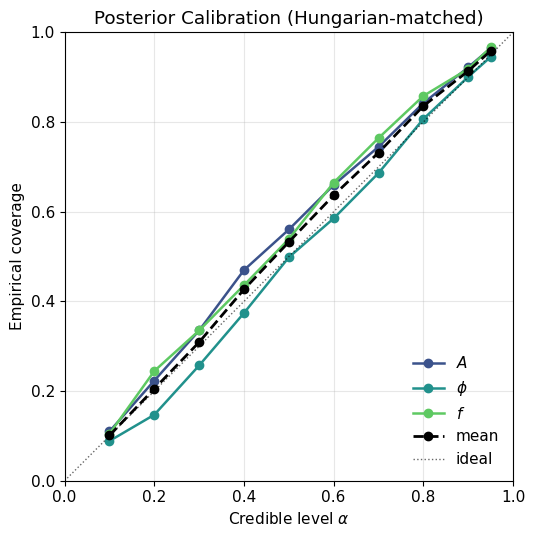


--- Empirical Coverage Summary ---
  α = 0.10 → coverage = 0.101 (ideal: 0.10)
  α = 0.20 → coverage = 0.205 (ideal: 0.20)
  α = 0.30 → coverage = 0.309 (ideal: 0.30)
  α = 0.40 → coverage = 0.427 (ideal: 0.40)
  α = 0.50 → coverage = 0.533 (ideal: 0.50)
  α = 0.60 → coverage = 0.637 (ideal: 0.60)
  α = 0.70 → coverage = 0.732 (ideal: 0.70)
  α = 0.80 → coverage = 0.836 (ideal: 0.80)
  α = 0.90 → coverage = 0.914 (ideal: 0.90)
  α = 0.95 → coverage = 0.959 (ideal: 0.95)

Average coverage bias = +0.020

Interpretation:
  - Positive bias: Underconfident (conservative, intervals too wide)
  - Negative bias: Overconfident (intervals too narrow)
  - For science: Slight positive bias is often preferred


In [5]:
# ================================================================
# Plot Calibration Curves
# ================================================================

latex_labels = {
    "amplitude": r"$A$",
    "phase": r"$\phi$",
    "frequency": r"$f$",
}

param_names = ["amplitude", "phase", "frequency"]
alphas_arr = calibration['alphas']

# Single combined plot
plt.figure(figsize=(6.5, 5.5))
colors = sns.color_palette("viridis", len(param_names))

for p, c in zip(param_names, colors):
    plt.plot(alphas_arr, calibration[p], "o-", lw=1.8, color=c, label=latex_labels[p])

plt.plot(alphas_arr, calibration['mean'], "o--", color="black", lw=2, label="mean")
plt.plot([0, 1], [0, 1], "k:", lw=1, alpha=0.6, label="ideal")

plt.xlabel(r"Credible level $\alpha$")
plt.ylabel("Empirical coverage")
plt.legend(frameon=False, loc="lower right")
plt.grid(True, which="both", alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect('equal')
plt.title("Posterior Calibration (Hungarian-matched)")
plt.tight_layout()
plt.show()

# Summary statistics
print("\n--- Empirical Coverage Summary ---")
for alpha, mean_cov in zip(alphas_arr, calibration['mean']):
    print(f"  α = {alpha:.2f} → coverage = {mean_cov:.3f} (ideal: {alpha:.2f})")
    
bias = np.mean(calibration['mean'] - alphas_arr)
print(f"\nAverage coverage bias = {bias:+.3f}")
print("\nInterpretation:")
print("  - Positive bias: Underconfident (conservative, intervals too wide)")
print("  - Negative bias: Overconfident (intervals too narrow)")
print("  - For science: Slight positive bias is often preferred")

## 3. Wasserstein Distance

Measure how different our posterior is from a reference (e.g., MCMC posterior).

In [6]:
# ================================================================
# Wasserstein Distance Implementation (with Hungarian Matching)
# ================================================================

def compute_wasserstein_1d(samples1, samples2):
    """
    Compute 1-Wasserstein distance between two 1D sample sets.
    """
    return wasserstein_distance(samples1, samples2)


@torch.no_grad()
def compute_posterior_distances(model, dataset, n_samples=30, n_posterior=500):
    """
    Compute Wasserstein distances between SlotFlow posteriors and 
    true parameter values using Hungarian matching.
    
    Uses the same matching strategy as training (based on flow log-prob).
    """
    freq_center = (FREQ_RANGE[0] + FREQ_RANGE[1]) / 2
    
    distances = {'amplitude': [], 'phase': [], 'frequency': []}
    
    for idx in tqdm(range(min(n_samples, len(dataset))), desc="Computing W-distances"):
        item = dataset[idx]
        
        # Handle different dataset modes
        if len(item) == 6:
            x_long, x_short, true_k, _, true_params, _ = item
        elif len(item) == 7:
            x_long, x_short, true_k, _, true_params, _, _ = item
        else:
            continue
        
        true_k = int(true_k)
        if true_k == 0:
            continue
            
        tp = true_params[:true_k]
        
        x_l = x_long.unsqueeze(0).to(device)
        x_s = x_short.unsqueeze(0).to(device)
        k_tensor = torch.tensor([true_k], device=device)
        output = model(x_l, x_s, use_gt_k=k_tensor)
        
        context = output['context']
        K_pred = int(output['K_pred'])
        
        if K_pred == 0:
            continue
        
        # Convert true params to flow representation for matching
        amp = tp[:, 0]
        phi = tp[:, 1]
        freq = tp[:, 2]
        true_params_4d = torch.stack(
            [amp, torch.cos(phi), torch.sin(phi), freq], dim=1
        ).to(device)
        
        # Hungarian matching based on flow log-prob
        gt_weighted = true_params_4d.clone()
        gt_weighted[:, 1:3] *= 2 # Phase weight
        gt_weighted[:, 3] -= freq_center
        gt_weighted[:, 3] *= 3 # Frequency weight
        
        ctx_exp = context.unsqueeze(0).expand(true_k, -1, -1)
        gt_exp = gt_weighted.unsqueeze(1).expand(-1, K_pred, -1)
        all_ctx = ctx_exp.reshape(-1, context.shape[-1])
        all_gt = gt_exp.reshape(-1, gt_weighted.shape[-1])
        
        logp = model.flow.log_prob(all_gt, context=all_ctx)
        cost = -logp.view(true_k, K_pred).detach().cpu().numpy()
        row_ind, col_ind = linear_sum_assignment(cost)
        
        if len(col_ind) == 0:
            continue
        
        # Sample posteriors and compute distances for matched pairs
        for true_k_idx, pred_k in zip(row_ind, col_ind):
            samples = model.flow.sample(n_posterior, context=context[pred_k:pred_k+1])
            samples = samples.squeeze(0).cpu().numpy()
            
            amp_samples = samples[:, 0]
            phase_samples = np.arctan2(samples[:, 2], samples[:, 1]) % (2*np.pi)
            freq_samples = samples[:, 3] / 3.0 + freq_center
            
            true_amp = tp[true_k_idx, 0].item()
            true_phase = tp[true_k_idx, 1].item() % (2*np.pi)
            true_freq = tp[true_k_idx, 2].item()
            
            # W1 distance to delta = mean |sample - true|
            distances['amplitude'].append(np.mean(np.abs(amp_samples - true_amp)))
            distances['frequency'].append(np.mean(np.abs(freq_samples - true_freq)))
            
            # Phase: handle circularity
            phase_diff = np.abs(phase_samples - true_phase)
            phase_diff = np.minimum(phase_diff, 2*np.pi - phase_diff)
            distances['phase'].append(np.mean(phase_diff))
    
    return {k: np.array(v) for k, v in distances.items()}

# Compute W-distances with Hungarian matching
w_distances = compute_posterior_distances(model, test_set, n_samples=30, n_posterior=500)

Computing W-distances: 100%|██████████| 30/30 [00:38<00:00,  1.27s/it]


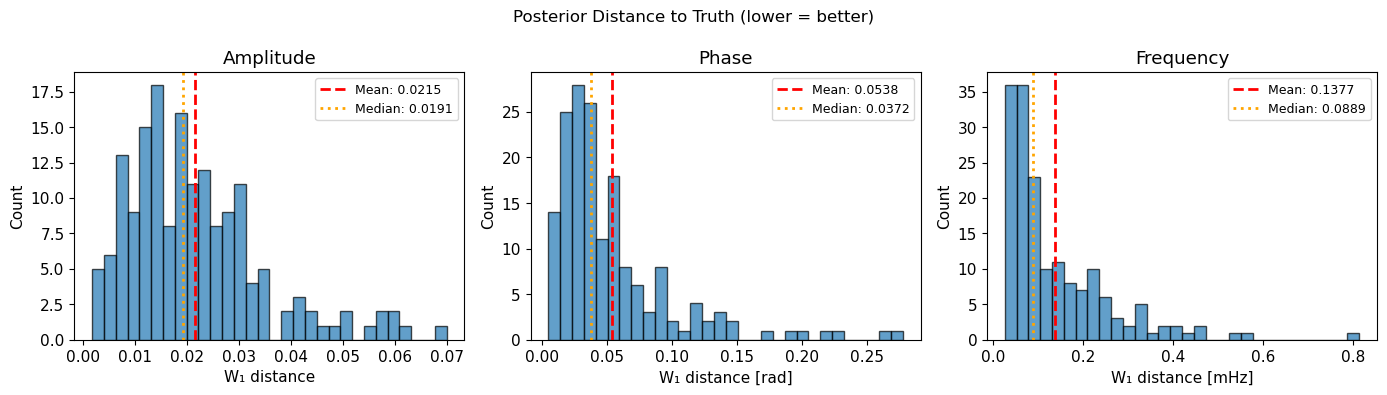


Summary statistics:
  amplitude   : mean = 0.0215 , std = 0.0131 
  phase       : mean = 0.0538 rad, std = 0.0480 rad
  frequency   : mean = 0.1377 mHz, std = 0.1205 mHz


In [7]:
# ================================================================
# Plot Wasserstein Distance Distributions
# ================================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

param_units = {'amplitude': '', 'phase': ' [rad]', 'frequency': ' [Hz]'}

for ax, param in zip(axes, ['amplitude', 'phase', 'frequency']):
    data = w_distances[param]
    
    if param == 'frequency':
        data = data * 1000  # Convert to mHz
        unit = ' [mHz]'
    else:
        unit = param_units[param]
    
    ax.hist(data, bins=30, alpha=0.7, edgecolor='black')
    ax.axvline(np.mean(data), color='red', ls='--', lw=2, label=f'Mean: {np.mean(data):.4f}')
    ax.axvline(np.median(data), color='orange', ls=':', lw=2, label=f'Median: {np.median(data):.4f}')
    ax.set_xlabel(f'W₁ distance{unit}')
    ax.set_ylabel('Count')
    ax.set_title(f'{param.capitalize()}')
    ax.legend(fontsize=9)

plt.suptitle('Posterior Distance to Truth (lower = better)', fontsize=12)
plt.tight_layout()
plt.show()

print("\nSummary statistics:")
for param in ['amplitude', 'phase', 'frequency']:
    data = w_distances[param]
    scale = 1000 if param == 'frequency' else 1
    unit = 'mHz' if param == 'frequency' else ('rad' if param == 'phase' else '')
    print(f"  {param:12s}: mean = {np.mean(data)*scale:.4f} {unit}, std = {np.std(data)*scale:.4f} {unit}")

## 4. Comprehensive Benchmark Suite

Let's design a benchmark that covers multiple aspects.

In [8]:
# ================================================================
# Benchmark Suite Design (with Hungarian Matching)
# ================================================================

class GBBenchmarkSuite:
    """
    Comprehensive benchmark suite for GB ML methods.
    
    Evaluates:
    1. Detection metrics (K accuracy, precision, recall)
    2. Parameter estimation (bias, variance, MSE) - uses Hungarian matching
    3. Uncertainty quantification (calibration, coverage)
    4. Computational performance
    """
    
    def __init__(self, model, dataset, device='cpu'):
        self.model = model
        self.dataset = dataset
        self.device = device
        self.results = {}
        self.freq_center = (FREQ_RANGE[0] + FREQ_RANGE[1]) / 2
    
    def _hungarian_match(self, context, true_params, true_k, K_pred):
        """
        Compute Hungarian matching between slots and true sources.
        
        Returns
        -------
        row_ind, col_ind : arrays
            Matching indices (true_idx, slot_idx pairs)
        """
        # Convert true params to flow representation
        amp = true_params[:, 0]
        phi = true_params[:, 1]
        freq = true_params[:, 2]
        true_params_4d = torch.stack(
            [amp, torch.cos(phi), torch.sin(phi), freq], dim=1
        ).to(self.device)
        
        # Apply normalization (same as training)
        gt_weighted = true_params_4d.clone()
        gt_weighted[:, 1:3] *= 2
        gt_weighted[:, 3] -= self.freq_center
        gt_weighted[:, 3] *= 3
        
        # Compute cost matrix
        ctx_exp = context.unsqueeze(0).expand(true_k, -1, -1)
        gt_exp = gt_weighted.unsqueeze(1).expand(-1, K_pred, -1)
        all_ctx = ctx_exp.reshape(-1, context.shape[-1])
        all_gt = gt_exp.reshape(-1, gt_weighted.shape[-1])
        
        logp = self.model.flow.log_prob(all_gt, context=all_ctx)
        cost = -logp.view(true_k, K_pred).detach().cpu().numpy()
        
        return linear_sum_assignment(cost)
    
    @torch.no_grad()
    def run_detection_benchmark(self, n_samples=200):
        """Evaluate detection metrics."""
        print("Running detection benchmark...")
        
        true_ks = []
        pred_ks = []
        
        for idx in tqdm(range(min(n_samples, len(self.dataset)))):
            sample = self.dataset[idx]
            x_long, x_short, true_k = sample[0], sample[1], sample[2]
            
            x_l = x_long.unsqueeze(0).to(self.device)
            x_s = x_short.unsqueeze(0).to(self.device)
            output = self.model(x_l, x_s)
            
            true_ks.append(true_k)
            pred_ks.append(output['K_pred'].item())
        
        true_ks = np.array(true_ks)
        pred_ks = np.array(pred_ks)
        
        self.results['detection'] = {
            'k_accuracy': np.mean(true_ks == pred_ks),
            'k_mae': np.mean(np.abs(true_ks - pred_ks)),
            'k_bias': np.mean(pred_ks - true_ks),
            'confusion_matrix': self._compute_confusion_matrix(true_ks, pred_ks),
        }
        
        return self.results['detection']
    
    def _compute_confusion_matrix(self, true_ks, pred_ks):
        """Compute K confusion matrix."""
        max_k = max(max(true_ks), max(pred_ks))
        cm = np.zeros((max_k, max_k), dtype=int)
        for t, p in zip(true_ks, pred_ks):
            cm[t-1, p-1] += 1
        return cm
    
    @torch.no_grad()
    def run_parameter_benchmark(self, n_samples=100, n_posterior=500):
        """
        Evaluate parameter estimation metrics using Hungarian matching.
        """
        print("Running parameter benchmark (with Hungarian matching)...")
        
        biases = {'amp': [], 'phase': [], 'freq': []}
        variances = {'amp': [], 'phase': [], 'freq': []}
        
        for idx in tqdm(range(min(n_samples, len(self.dataset)))):
            sample = self.dataset[idx]
            x_long, x_short, true_k = sample[0], sample[1], sample[2]
            true_params = sample[4][:true_k]
            true_k = int(true_k)
            
            if true_k == 0:
                continue
            
            x_l = x_long.unsqueeze(0).to(self.device)
            x_s = x_short.unsqueeze(0).to(self.device)
            k_tensor = torch.tensor([true_k], device=self.device)
            output = self.model(x_l, x_s, use_gt_k=k_tensor)
            
            context = output['context']
            K_pred = int(output['K_pred'])
            
            if K_pred == 0:
                continue
            
            # Hungarian matching
            row_ind, col_ind = self._hungarian_match(context, true_params, true_k, K_pred)
            
            # Evaluate matched pairs
            for true_idx, slot_idx in zip(row_ind, col_ind):
                samples = self.model.flow.sample(n_posterior, context=context[slot_idx:slot_idx+1])
                samples = samples.squeeze(0).cpu().numpy()
                
                amp = samples[:, 0]
                phase = np.arctan2(samples[:, 2], samples[:, 1]) % (2*np.pi)
                freq = samples[:, 3] / 3.0 + self.freq_center
                
                true_amp = true_params[true_idx, 0].item()
                true_phase = true_params[true_idx, 1].item() % (2*np.pi)
                true_freq = true_params[true_idx, 2].item()
                
                biases['amp'].append(np.mean(amp) - true_amp)
                biases['freq'].append(np.mean(freq) - true_freq)
                variances['amp'].append(np.var(amp))
                variances['freq'].append(np.var(freq))
                
                # Phase bias (circular)
                phase_diff = np.mean(phase) - true_phase
                phase_diff = (phase_diff + np.pi) % (2*np.pi) - np.pi
                biases['phase'].append(phase_diff)
                variances['phase'].append(np.var(phase))
        
        self.results['parameters'] = {
            'amp_bias_mean': np.mean(biases['amp']),
            'amp_bias_std': np.std(biases['amp']),
            'amp_variance_mean': np.mean(variances['amp']),
            'freq_bias_mean': np.mean(biases['freq']),
            'freq_bias_std': np.std(biases['freq']),
            'freq_variance_mean': np.mean(variances['freq']),
            'phase_bias_mean': np.mean(biases['phase']),
            'phase_bias_std': np.std(biases['phase']),
        }
        
        return self.results['parameters']
    
    def run_timing_benchmark(self, n_samples=50):
        """Evaluate computational performance."""
        import time
        print("Running timing benchmark...")
        
        times = []
        
        for idx in range(min(n_samples, len(self.dataset))):
            sample = self.dataset[idx]
            x_long, x_short = sample[0], sample[1]
            
            x_l = x_long.unsqueeze(0).to(self.device)
            x_s = x_short.unsqueeze(0).to(self.device)
            
            # Warm up
            if idx == 0:
                with torch.no_grad():
                    _ = self.model(x_l, x_s)
            
            # Time inference
            start = time.perf_counter()
            with torch.no_grad():
                _ = self.model(x_l, x_s)
            end = time.perf_counter()
            
            times.append(end - start)
        
        self.results['timing'] = {
            'mean_ms': np.mean(times) * 1000,
            'std_ms': np.std(times) * 1000,
            'median_ms': np.median(times) * 1000,
        }
        
        return self.results['timing']
    
    def run_all(self):
        """Run all benchmarks."""
        self.run_detection_benchmark()
        self.run_parameter_benchmark()
        self.run_timing_benchmark()
        return self.results
    
    def print_summary(self):
        """Print benchmark summary."""
        print("\n" + "="*60)
        print("BENCHMARK SUMMARY")
        print("="*60)
        
        if 'detection' in self.results:
            d = self.results['detection']
            print(f"\nDETECTION:")
            print(f"  K accuracy: {d['k_accuracy']:.1%}")
            print(f"  K MAE: {d['k_mae']:.3f}")
            print(f"  K bias: {d['k_bias']:+.3f}")
        
        if 'parameters' in self.results:
            p = self.results['parameters']
            print(f"\nPARAMETER ESTIMATION (Hungarian-matched):")
            print(f"  Amplitude bias: {p['amp_bias_mean']:.4f} ± {p['amp_bias_std']:.4f}")
            print(f"  Frequency bias: {p['freq_bias_mean']*1000:.4f} ± {p['freq_bias_std']*1000:.4f} mHz")
            print(f"  Phase bias: {p['phase_bias_mean']:.4f} ± {p['phase_bias_std']:.4f} rad")
        
        if 'timing' in self.results:
            t = self.results['timing']
            print(f"\nCOMPUTATIONAL:")
            print(f"  Inference time: {t['mean_ms']:.2f} ± {t['std_ms']:.2f} ms")

# Run benchmark
benchmark = GBBenchmarkSuite(model, test_set, device=device)
results = benchmark.run_all()
benchmark.print_summary()

Running detection benchmark...


100%|██████████| 200/200 [00:03<00:00, 65.63it/s]


Running parameter benchmark (with Hungarian matching)...


100%|██████████| 100/100 [04:01<00:00,  2.42s/it]


Running timing benchmark...

BENCHMARK SUMMARY

DETECTION:
  K accuracy: 100.0%
  K MAE: 0.000
  K bias: +0.000

PARAMETER ESTIMATION (Hungarian-matched):
  Amplitude bias: -0.0008 ± 0.0204
  Frequency bias: -0.0103 ± 0.1736 mHz
  Phase bias: 0.0054 ± 0.3238 rad

COMPUTATIONAL:
  Inference time: 10.61 ± 0.67 ms


---

## Project Extensions

**Ideas for workshop projects:**

1. **Add more metrics**: Implement precision/recall for source matching

2. **Stratified analysis**: Break down by K, SNR, Δf

3. **Comparison framework**: Run same benchmarks on different methods

4. **Visualization dashboard**: Create summary plots

5. **Catalog-level metrics**: Evaluate entire catalog quality

---

In [9]:
# ================================================================
# YOUR TURN: Extend the Benchmark Suite
# ================================================================

# TODO: Add stratified analysis by K
#
# def run_stratified_benchmark(self, n_samples=200):
#     """Run benchmark stratified by true K."""
#     results_by_k = {}
#     for k in range(1, self.model.max_slots + 1):
#         # Filter dataset to samples with this K
#         # Run metrics
#         pass
#     return results_by_k